# Batch filter and render "Codeless" Jupyter Notebook

This notebook allows you to filter and render a super-resolution image from localizations generated by Picasso localization software and then assess quality control metrics such as Decorrelation analysis.

To use this notebook you don't need to interact with any code, just run cells in order and a graphical user interface will pop-up showcasing the parameters for each step. Output will be saved on the same directory as the loaded image.

The only requirements for this code is to have python >= 3.9 and to install the libraries Nanopyx (https://github.com/HenriquesLab/NanoPyx) and Picasso (https://github.com/jungmannlab/picasso). 

To install run the notebook, please create an environment with the proper libraries as in the following example:

1. Open the console/terminal and create a new conda environment: `conda create --name picasso python=3.10`.
2. Activate the environment: `conda activate picasso`.
3. Install Nanopyx and Picasso packages using: `pip install nanopyx[jupyter]` and `pip install picassosr`.
4. Run the cells in the notebook using the environment.

**Nanopyx**: Bruno M. Saraiva, Inês M. Cunha, António D. Brito, Gautier Follain, Raquel Portela, Robert Haase, Pedro M. Pereira, Guillaume Jacquemet, Ricardo Henriques bioRxiv 2023.08.13.553080; doi: https://doi.org/10.1101/2023.08.13.553080 

**Picasso**: Schnitzbauer, J., Strauss, M., Schlichthaerle, T. et al. Super-resolution microscopy with DNA-PAINT. Nat Protoc 12, 1198–1228 (2017). https://doi.org/10.1038/nprot.2017.024

**DecorrAnalysis**: Descloux A, Grußmayer KS, Radenovic A. Parameter-free image resolution estimation based on decorrelation analysis. Nat Methods. 2019 Sep;16(9):918-924. https://10.1038/s41592-019-0515-7 

In [1]:
# !pip install -q "nanopyx[all]"
# !pip install picassosr

import io
import os

%matplotlib inline

import numpy as np
from matplotlib import colormaps
from matplotlib import pyplot as plt
import seaborn as sns
import tifffile
from pylab import *

from IPython.display import display, clear_output
import ipywidgets as widgets
from PIL import Image

from picasso import render
from picasso import io as picasso_io

from nanopyx.core.analysis.decorr import DecorrAnalysis
from nanopyx.core.utils.easy_gui import EasyGui
from nanopyx.core.utils.find_files import find_files

/Users/avesga/miniforge3/envs/nanopicasso/lib/python3.10/site-packages/pytools/persistent_dict.py:52: RecommendedHashNotFoundWarning: Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.
  warn("Unable to import recommended hash 'siphash24.siphash13', "


Cupy implementation is not available. Make sure you have the right version of Cupy and CUDA installed.
Optional dependecy Dask_image is not installed. Implementations using it will be ignored.


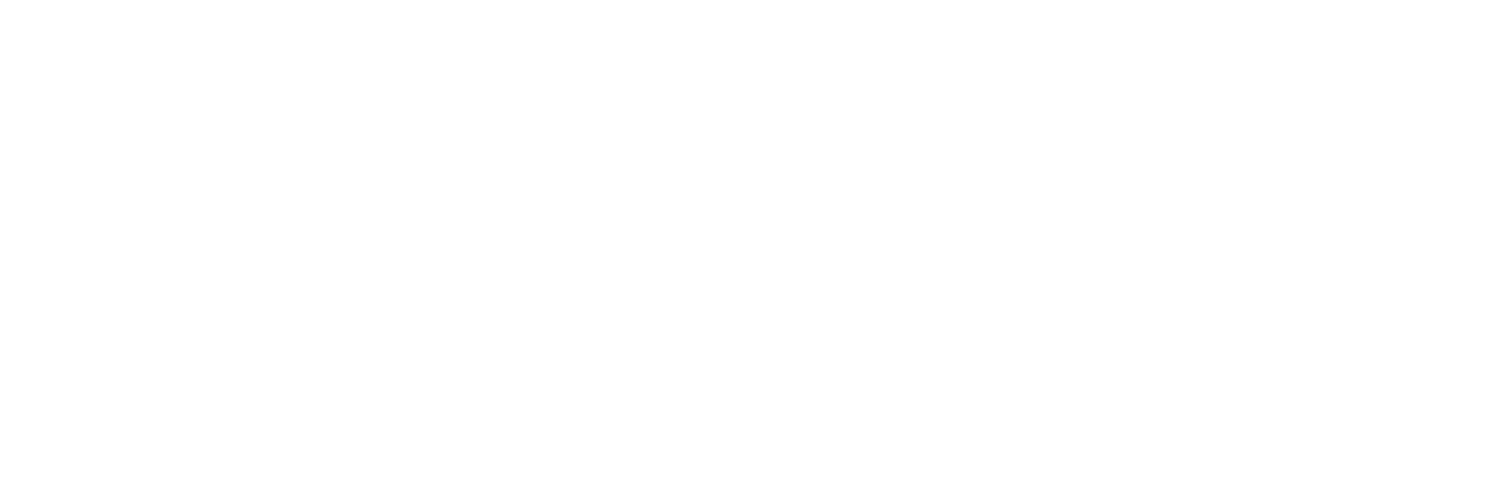

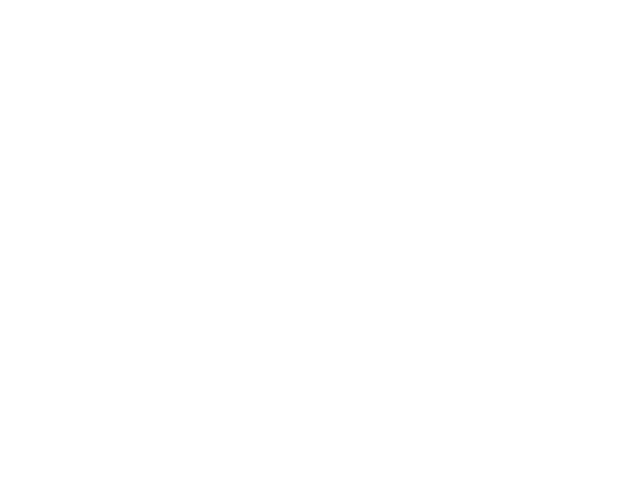

In [ ]:
#@title Load image stack
# Create a GUI
gui_data = EasyGui("Data Loader")
global own_data
own_data = True

def plot_histograms(dataset_original):
    global max_photons_hist
    global max_sigma_hist
    global max_bkg_hist

    max_photons_hist = np.max(dataset_original.photons)
    max_sigma_hist = np.max(dataset_original.sx)
    max_bkg_hist = np.max(dataset_original.bg)

    if max_photons_hist > 20000:
        max_photons_hist = 20000
    if max_sigma_hist > 10:
        max_sigma_hist = 10

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    sns.histplot(ax=axs[0], data=dataset_original.photons, binrange=(0, max_photons_hist), color='red')
    axs[0].set_title('Photons')
    sns.histplot(ax=axs[1], data=dataset_original.sx, binrange=(0, max_sigma_hist), color='blue')
    axs[1].set_title('Localization uncertainty (sigma)')
    sns.histplot(ax=axs[2], data=dataset_original.bg, color='black')
    axs[2].set_title('Background of localizations')

    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")

    output_plot = widgets.Output()
    with output_plot:
        display(Image.open(img_buf))
                
    plt.clf()

    return output_plot

def render_data(locs_render):

    # Render the image
    x_min = np.min(locs_render.x)
    x_max = np.max(locs_render.x)
    y_min = np.min(locs_render.y)
    y_max = np.max(locs_render.y)

    viewport_full = (y_min, x_min), (y_max, x_max)

    len_x, image = render.render(locs_render, viewport=viewport_full, oversampling=1, blur_method='gaussian_iso')

    fig, ax = plt.subplots()
    plt.imshow(image, interpolation = 'sinc', vmin = 0, vmax = max(image.flatten())*0.01, cmap=gui_data["cmaps"].value)
    plt.title('Rendered image before filtering')
    plt.axis("off")
    # plt.show()
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    output_plot = widgets.Output()
    with output_plot:
        display(Image.open(img_buf))

    plt.clf()

    return output_plot

def on_button_load_data_clicked(b):
    clear_output()
    gui_data.show()
    global dataset_original
    global own_data
    global path
    global file_save

    # extract the path without the filename from gui_filter_render["upload"].selected
    path = gui_data["upload"].selected.split("/")[:-1]
    # make path a str
    path = "/".join(path)
    file_save = gui_data["upload"].value.split("/")[-1]

    own_data = True
    # disable button
    gui_data["load_data_own"].disabled = True
    gui_data["load_data_own"].description = "Loading..."

    dataset_original, info = picasso_io.load_locs(gui_data["upload"].selected)
    
    gui_data["load_data_own"].disabled = False
    gui_data["load_data_own"].description = "Load data"
    image_hist = plot_histograms(dataset_original)
    image_render = render_data(dataset_original)

    gui_data._main_display.children = gui_data._main_display.children + (image_hist, image_render, )
    plt.clf()


clear_output()
gui_data.add_label("Select data to use:")
gui_data.add_file_upload("upload", accept="*hdf5")
gui_data.add_dropdown("cmaps", description="Colormap:",
                    options=sorted(list(colormaps)),
                    value="gray", remember_value=False)
gui_data.add_button("load_data_own", description="Load data")
gui_data["load_data_own"].on_click(on_button_load_data_clicked)

gui_data.show()

# Filter localizations 

The loaded localizations can be filtered according to photon number and sigma of the fitted gaussian of every localization. First, select the high and low bounds for both photons and sigma. Then select the oversampling desired for the rendering.

A central ROI to filter and render can be set unticking the checkbox and selectig the lateral size of the ROI in the original image.

## Filtering serial data

Once the parameters are satisfactory, a whole folder can be analyzed by pressing **Filter and render a folder** button. Then all the *.hdf5 files within the folder will be filtered and rendered with the selected parameters. Please note that there has to be always a pair of *.hdf5 and *.yaml files with the same name.

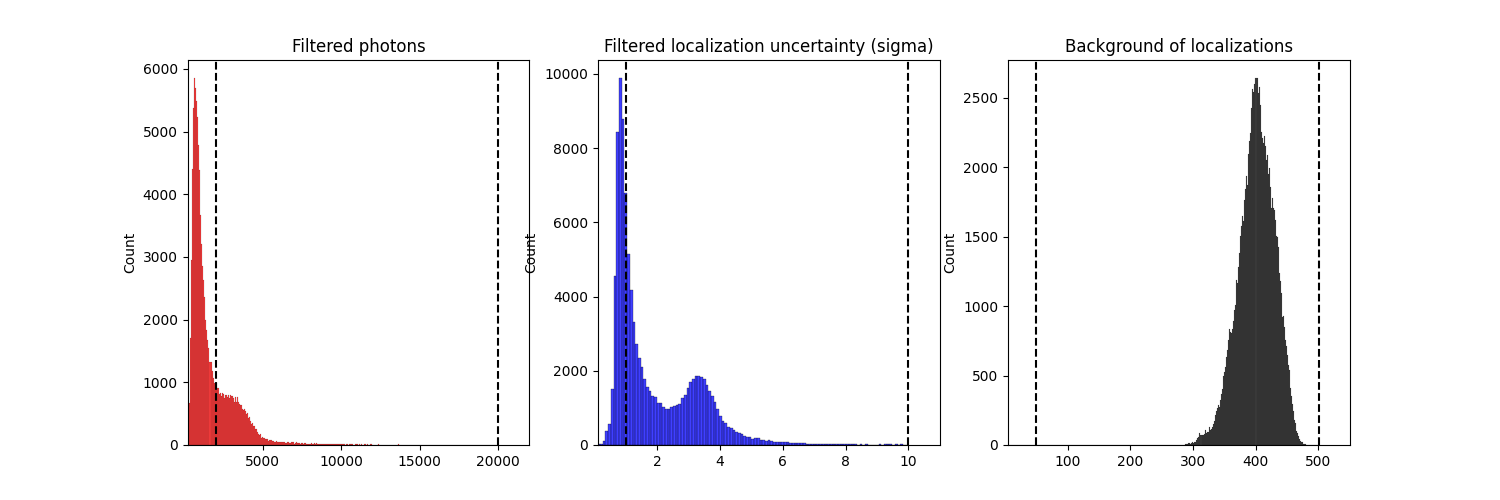

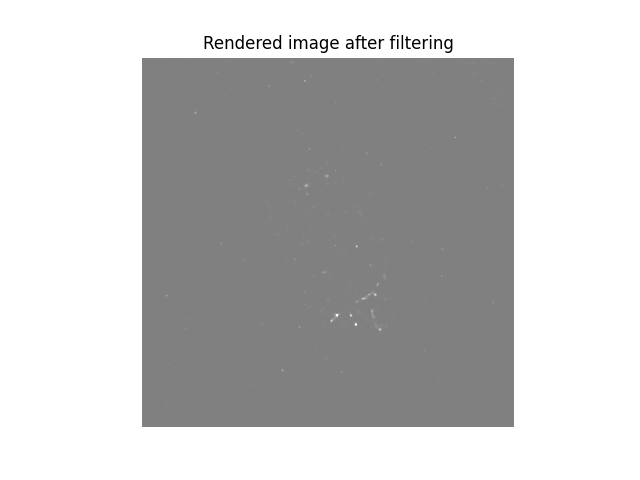

No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: b6a8547fecab46c2af37853848ee990e
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 26f4a6f48f014e158e4e0df48f84d87d
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: 2baa2d946c534f9aacd7f24d4cc5b394
No such comm: ea2066a6d77f4a1f8dd4a48302f2fdcc
No such comm: ea2066a6d77f4a1f8dd4a48302f2fdcc
No such comm: ea2066a6d77f4a1f8dd4a48302f2fdcc
No such comm:

In [ ]:
gui_filter_render = EasyGui("Select Filters")

%matplotlib widget

def filter_locs(locs, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg, high_bound_bkg):

    print("Filtering out locs with uncertainty > ", lower_bound_sigma, "uncertainty < ", upper_bound_sigma, "and photons > ", lower_bound_photons, "and < ", upper_bound_photons, "and bkg < ", lower_bound_bkg, "and > ", high_bound_bkg)

    locs = locs[(locs['sx'] > lower_bound_sigma) & (locs['sx'] < upper_bound_sigma) & (locs['sy'] > lower_bound_sigma) & (locs['sy'] < upper_bound_sigma)]
    locs = locs[(locs['photons'] > lower_bound_photons) & (locs['photons'] < upper_bound_photons)]
    locs = locs[(locs['bg'] > lower_bound_bkg) & (locs['bg'] < high_bound_bkg)]

    if any(locs['sx'] != locs['sy']):
        # Filter all gaussians with either of the axes bigger than 3 times the other one
        print("Filtering out locs with sx/sy > ", 3)
        locs = locs[(locs['sx']/locs['sy'] < 3) | (locs['sx']/locs['sy'] > 3)]

    return locs

def plot_and_save_histogram(x, file_save, title, color, xlim, path):
    fig, ax = plt.subplots()
    transparent = False

    ax.set_xlim(xlim)
    y, x, _ = hist(x, 1000, alpha=0.3, label='data', color=color) 
    plt.title(title)
    fig.savefig(os.path.join(path, f"{file_save}_{title.lower()}.png"), transparent=transparent)

def extract_histogram(path, file_save, locs, appendix):

    plot_and_save_histogram(locs.photons, file_save, 'Photon Distribution'+appendix, 'red', (0, max_photons_hist), path)
    plot_and_save_histogram(locs.sx, file_save, 'Uncertainty'+appendix, 'blue', (0, max_sigma_hist), path)

    # Plot detecttions per frame
    fig, ax = plt.subplots()
    sns.histplot(locs.frame, kde=False, color='orange')
    # Total number of localizations
    total_localizations = len(locs)
    plt.title('Detections per frame'+appendix+"with total_localizations = "+str(total_localizations))
    fig.savefig(os.path.join(path, f"{file_save}_detec_frame{appendix}.png"), transparent=False)
    plt.close('all')

def plot_histograms_filter(dataset_original, photons_low, photons_high, sigma_low, sigma_high, bkg_low, bkg_high):

    fig, axsh = plt.subplots(1, 3, figsize=(15, 5))

    sns.histplot(ax=axsh[0], data=dataset_original.photons, binrange=(0, max_photons_hist), color='red')
    # set x axis 
    axsh[0].set_xlim(photons_low*0.1 , photons_high + photons_high*0.1)
    # add vertical lines for the lower and upper bounds
    axsh[0].axvline(x=photons_low, color='black', linestyle='--')
    axsh[0].axvline(x=photons_high, color='black', linestyle='--')
    axsh[0].set_title('Filtered photons')

    sns.histplot(ax=axsh[1], data=dataset_original.sx, binrange=(0, max_sigma_hist), color='blue')
    axsh[1].set_xlim(sigma_low*0.1 , sigma_high + sigma_high*0.1)
    # add vertical lines for the lower and upper bounds
    axsh[1].axvline(x=sigma_low, color='black', linestyle='--')
    axsh[1].axvline(x=sigma_high, color='black', linestyle='--')
    axsh[1].set_title('Filtered localization uncertainty (sigma)')

    sns.histplot(ax=axsh[2], data=dataset_original.bg, binrange=(0, max_bkg_hist), color='black')
    axsh[2].set_xlim(bkg_low*0.1 , bkg_high + bkg_high*0.1)
    # add vertical lines for the lower and upper bounds
    axsh[2].axvline(x=bkg_low, color='black', linestyle='--')
    axsh[2].axvline(x=bkg_high, color='black', linestyle='--')
    axsh[2].set_title('Background of localizations')
    
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    output_plot = widgets.Output()
    with output_plot:
        display(Image.open(img_buf))

    return output_plot

def extract_render_save(path, file_save, dataset_original, roi_size, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg, high_bound_bkg, use_full_roi):

    extract_histogram(path, file_save, dataset_original, "_before filtering")
    locs_filtered = filter_locs(dataset_original, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg, high_bound_bkg)
    extract_histogram(path, file_save, locs_filtered, "_after filtering")

    # Render the image
    x_min = np.min(dataset_original.x)
    x_max = np.max(dataset_original.x)
    y_min = np.min(dataset_original.y)
    y_max = np.max(dataset_original.y)

    x_min_center = (x_max - x_min)//2 - roi_size//2
    x_max_center = (x_max - x_min)//2 + roi_size//2
    y_min_center = (y_max - y_min)//2 - roi_size//2
    y_max_center = (y_max - y_min)//2 + roi_size//2

    if use_full_roi:
        viewport = (y_min, x_min), (y_max, x_max)
    else:
        viewport = (y_min_center, x_min_center), (y_max_center, x_max_center)

    len_x, image = render.render(dataset_original, viewport=viewport, oversampling=1, blur_method='gaussian_iso')
    print("Saving redered image before filtering")
    tifffile.imwrite(os.path.join(path, f"{file_save}_rendered_before_filter.tif"), image)

    len_x, image_oversampling = render.render(locs_filtered, viewport=viewport, oversampling=oversampling, blur_method='gaussian_iso')
    print("Saving redered image after filtering")
    tifffile.imwrite(os.path.join(path, f"{file_save}_rendered.tif"), image_oversampling)

    return image_oversampling

def analyze_dataset_folder(b):
    path = gui_filter_render["upload"].selected.split("/")[:-1]
    # make path a str
    path = "/".join(path)
    # Create a folder in path called "analysis"
    path_save = os.path.join(path, "analysis")
    if not os.path.exists(path_save):
        os.makedirs(path_save)
    
    # Run over the *.hdf5 files in path
    files = find_files(path, "hdf5")
    print(files)

    for file in files:

        file_save_folder = file.split("/")[-1]
        print("Analyzing ", file_save_folder)

        dataset_folder, info = picasso_io.load_locs(file)
        locs_filtered = filter_locs(dataset_folder, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg,  upper_bound_bkg)
        image_oversampling = extract_render_save(path_save, file_save_folder, dataset_folder, roi_size, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg,  upper_bound_bkg, use_full_roi)

def analyze_dataset(b):

    gui_filter_render.save_settings()
    
    global lower_bound_sigma
    global upper_bound_sigma
    global lower_bound_photons
    global upper_bound_photons
    global lower_bound_bkg
    global upper_bound_bkg
    global roi_size
    global use_full_roi
    global oversampling
    global image_oversampling

    # if first_click exists
    if not 'first_click' in globals():
        global first_click
        first_click = True

    lower_bound_sigma = float(gui_filter_render["sigma_low"].value)
    upper_bound_sigma = float(gui_filter_render["sigma_high"].value)
    lower_bound_photons = float(gui_filter_render["photons_low"].value)
    upper_bound_photons = float(gui_filter_render["photons_high"].value)
    lower_bound_bkg = float(gui_filter_render["bkg_low"].value)
    upper_bound_bkg = float(gui_filter_render["bkg_high"].value)

    oversampling = int(gui_filter_render["magnification"].value)
    roi_size = int(gui_filter_render["roi_size"].value)
    use_full_roi = gui_filter_render["use_full_roi"].value

    gui_filter_render["filter_render"].disabled = True
    gui_filter_render["filter_render"].description = "Running..."

    image_oversampling = extract_render_save(path, file_save, dataset_original, roi_size, lower_bound_sigma, upper_bound_sigma, lower_bound_photons, upper_bound_photons, lower_bound_bkg,  upper_bound_bkg, use_full_roi)

    gui_filter_render["filter_render"].disabled = False
    gui_filter_render["filter_render"].description = "Filter and render"

    image_hist = plot_histograms_filter(dataset_original, lower_bound_photons, upper_bound_photons, lower_bound_sigma, upper_bound_sigma, lower_bound_bkg, upper_bound_bkg)
    
    fig, axs = plt.subplots()

    axs.imshow(image_oversampling, alpha=0.5, vmin=0, vmax=max(image_oversampling.flatten())*0.1, cmap=gui_data["cmaps"].value)
    axs.axis("off")
    axs.set_title('Rendered image after filtering')

    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    rendered_plot = widgets.Output()
    with rendered_plot:
        display(Image.open(img_buf))

    # If this was sucessfull, enable analyze whole folder save
    if first_click:
        first_click = False

        gui_filter_render.add_label("--------------------")
        gui_filter_render.add_label("If these parameters are satisfactory, you can analyze a full folder.")
        gui_filter_render.add_label("Select the folder to analyze:")

    gui_filter_render["update_histograms"].disabled = False

    gui_filter_render.add_file_upload("upload")
    gui_filter_render.add_button("filter_render_folder", description="[Optional] Filter and render a folder")
    gui_filter_render["filter_render_folder"].on_click(analyze_dataset_folder)
    
    gui_filter_render.show()

    gui_filter_render._main_display.children = gui_filter_render._main_display.children + (image_hist, rendered_plot)


def update_plot(b):

    lower_bound_sigma = float(gui_filter_render["sigma_low"].value)
    upper_bound_sigma = float(gui_filter_render["sigma_high"].value)
    lower_bound_photons = float(gui_filter_render["photons_low"].value)
    upper_bound_photons = float(gui_filter_render["photons_high"].value)
    lower_bound_bkg = float(gui_filter_render["bkg_low"].value)
    upper_bound_bkg = float(gui_filter_render["bkg_high"].value)

    image_hist = plot_histograms_filter(dataset_original, lower_bound_photons, upper_bound_photons, lower_bound_sigma, upper_bound_sigma, lower_bound_bkg, upper_bound_bkg)
    gui_filter_render._main_display.children = gui_filter_render._main_display.children + (image_hist, )

    gui_filter_render.show()

gui_filter_render.add_label("Select filters:")

gui_filter_render.add_float_slider("photons_low", description="Lower photons bound:", min=0, max=max_photons_hist, value=max_photons_hist*0.1)
gui_filter_render.add_float_slider("photons_high", description="Upper photons bound:", min=0, max=max_photons_hist, value=max_photons_hist)

gui_filter_render.add_float_slider("sigma_low", description="Lower sigma bound:", min=0, max=max_sigma_hist, value=max_sigma_hist*0.1)
gui_filter_render.add_float_slider("sigma_high", description="Upper sigma bound:", min=0, max=max_sigma_hist, value=max_sigma_hist)

gui_filter_render.add_float_slider("bkg_low", description="Lower background bound:", min=0, max=max_bkg_hist, value=max_bkg_hist*0.1)
gui_filter_render.add_float_slider("bkg_high", description="Upper background bound:", min=0, max=max_bkg_hist, value=1000)

gui_filter_render.add_label("Select magnification in reconstruction:")
gui_filter_render.add_int_slider("magnification", description="Magnification:", min=0, max=15, value=2)

gui_filter_render.add_label("Select central ROI size:")
gui_filter_render.add_int_slider("roi_size", description="ROI size (px):", min=0, max=4000, value=200)
gui_filter_render.add_checkbox("use_full_roi", description="Use full ROI", value=True)

gui_filter_render.add_button("filter_render", description="Filter and render loaded file")
gui_filter_render["filter_render"].on_click(analyze_dataset)

gui_filter_render.add_button("update_histograms", description="Update the histograms")
gui_filter_render["update_histograms"].on_click(update_plot)
gui_filter_render["update_histograms"].disabled = True

gui_filter_render.show()


## Calculate Decorrelation analysis resolution of the SR image
### Image Decorrelation Analysis Parameters:

- **Pixel Size:** Pixel size of the image. Used to calculte resolution values.
- **Units:** Pixel size units.
- **Radius Min/Max:** Resolution calculation by Decorrelation Analysis is performed in the frequency space. These parameters define the range of radii to be used in the calculation. 


In [ ]:
gui_decorr = EasyGui("DecorrAnalysis")

def run_decorr(b):
    clear_output()
    gui_decorr.show()
    gui_decorr.save_settings()
    pixel_size = gui_decorr["pixel_size"].value
    units = gui_decorr["units"].value
    rmin = gui_decorr["rmin"].value
    rmax = gui_decorr["rmax"].value
    gui_decorr["run"].disabled = True
    gui_decorr["run"].description = "Calculating..."
    global decorr_calculator
    decorr_calculator = DecorrAnalysis(pixel_size=pixel_size/oversampling, units=units, rmin=rmin, rmax=rmax)
    decorr_calculator.run_analysis(image_oversampling)
    gui_decorr["run"].disabled = False
    gui_decorr["run"].description = "Calculate"
    plot = decorr_calculator.plot_results()
    plt.imshow(plot)
    plt.savefig(os.path.join(path, f"{file_save}_decorrelation.png"), dpi=300)
    plt.axis("off")
    img_buf = io.BytesIO()
    plt.savefig(img_buf, format="jpeg")
    output_plot = widgets.Output()
    with output_plot:
        display(Image.open(img_buf))
    gui_decorr._main_display.children = gui_decorr._main_display.children + (widgets.Label(value="Real pixel size of rendered image is: " + str(pixel_size/oversampling) + "nm for magnification " + str(oversampling) + "x"),output_plot,)
    plt.clf()

gui_decorr.add_int_slider("pixel_size", description="Experimental Pixel Size:", min=0.01, max=1000, value=65, remember_value=False)
gui_decorr.add_dropdown("units", description="Units: ", options=["nm", "um", "mm"], value="nm")
gui_decorr.add_float_slider("rmin", description="Radius Min:", min=0.0, max=0.5, value=0.0)
gui_decorr.add_float_slider("rmax", description="Radius Max:", min=0.5, max=1.0, value=1.0)
gui_decorr.add_checkbox("save", description="Save Output", value=True)
gui_decorr.add_button("run", description="Calculate")
gui_decorr["run"].on_click(run_decorr)
gui_decorr.show()

No such comm: f00e4693937d4f2e97eadec8c83218e6
No such comm: f00e4693937d4f2e97eadec8c83218e6
No such comm: f00e4693937d4f2e97eadec8c83218e6
No such comm: f00e4693937d4f2e97eadec8c83218e6
No such comm: f00e4693937d4f2e97eadec8c83218e6
No such comm: f00e4693937d4f2e97eadec8c83218e6
